# AI Search Isn't Cutting Your Leads — It's Filtering Them

*Paid search in the answer-engine era.*

A narrative walk-through of the analysis. The reusable logic lives in
`src/analysis.py`; this notebook imports it so the story and the script never
drift apart.

**The data is synthetic but research-informed** (see the README for sources and
assumptions). The contribution is the *method and the decision*, not real
advertiser numbers.

**Storyline:** total paid-search leads fall (the alarm) -> the drop is
concentrated in informational queries hit by AI Overviews (the mechanism) -> the
remaining leads are higher quality (the twist) -> reallocate, don't cut (the
decision).

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Make src/ importable and reuse the exact analysis logic from the script.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import analysis as A  # noqa: E402

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

df = A.load_data()
nonbrand = df[~df["is_branded"]].copy()
brand = df[df["is_branded"]].copy()
print(f"rows={len(df)} | weeks={df['week'].nunique()} | "
      f"non-brand rows={len(nonbrand)} | brand rows={len(brand)}")
df.head()

rows=832 | weeks=52 | non-brand rows=728 | brand rows=104


,week,query_intent,ai_overview_present,campaign_type,landing_page_type,impressions,clicks,cost,leads,qualified_leads,...,is_branded,ctr,cpc,conversion_rate,cost_per_lead,cost_per_qualified_lead,qualified_lead_rate,cac,roas,revenue_per_visitor
0,2024-06-24,informational,yes,search,generic,31167,807,"1,096.23",14,1,...,False,0.03,1.36,0.02,78.30,"1,096.23",0.07,NaN,0.00,0.00
1,2024-06-24,informational,no,search,generic,131289,7214,"8,295.33",153,14,...,False,0.05,1.15,0.02,54.22,592.52,0.09,"8,295.33",0.10,0.12
2,2024-06-24,commercial,yes,search,comparison,4748,186,670.17,10,4,...,False,0.04,3.60,0.05,67.02,167.54,0.40,NaN,0.00,0.00
3,2024-06-24,commercial,no,search,comparison,56672,2744,"9,530.08",133,57,...,False,0.05,3.47,0.05,71.65,167.19,0.43,"1,361.44",2.24,7.79
4,2024-06-24,commercial,yes,search,calculator,2326,101,374.10,6,3,...,False,0.04,3.70,0.06,62.35,124.70,0.50,NaN,0.00,0.00


## Cleaning footprint

Three decisions worth seeing before any chart: (1) **branded** queries are split
out and excluded from the erosion story; (2) **zero-spend / zero-click** rows
(the Q3 budget freeze) exist and are handled with NaN-safe division; (3) rate
aggregates are derived from **summed** numerators/denominators, not averages of
per-row rates.

In [2]:
print(f"zero-click rows : {(df['clicks'] == 0).sum()}")
print(f"zero-spend rows : {(df['cost'] == 0).sum()}")
print(f"branded rows    : {len(brand)} (excluded from erosion analysis)")

# Spot-check that rate metrics on a zero-spend week are NaN, not 0 or inf.
frozen = df[(df["query_intent"] == "transactional") & (df["campaign_type"] == "pmax") &
            (df["cost"] == 0)]
frozen[["week", "clicks", "cost", "cost_per_qualified_lead", "ctr", "roas"]].head()

zero-click rows : 8
zero-spend rows : 8
branded rows    : 104 (excluded from erosion analysis)


,week,clicks,cost,cost_per_qualified_lead,ctr,roas
302,2024-10-28,0,0.00,NaN,NaN,NaN
303,2024-10-28,0,0.00,NaN,NaN,NaN
318,2024-11-04,0,0.00,NaN,NaN,NaN
319,2024-11-04,0,0.00,NaN,NaN,NaN
334,2024-11-11,0,0.00,NaN,NaN,NaN


## Step 1 — The alarm, and Step 3 — The twist

Headline movements over the year (first 8 weeks vs last 8 weeks, non-brand).

In [3]:
h = A.headline_changes(nonbrand)
pd.DataFrame([
    ["Weekly leads",          f"{h['leads_first']:.0f}", f"{h['leads_last']:.0f}", f"{h['leads_change']:+.1f}%"],
    ["Qualified-lead rate",   f"{h['qr_first']*100:.1f}%", f"{h['qr_last']*100:.1f}%", f"{h['qr_change']:+.1f}%"],
    ["Qualified leads/wk",    f"{h['ql_first']:.0f}", f"{h['ql_last']:.0f}", f"{h['ql_change']:+.1f}%"],
    ["Revenue per visitor",   f"${h['rpv_first']:.2f}", f"${h['rpv_last']:.2f}", f"{h['rpv_change']:+.1f}%"],
], columns=["Metric", "First 8 wks", "Last 8 wks", "Change"])

,Metric,First 8 wks,Last 8 wks,Change
0,Weekly leads,662,489,-26.1%
1,Qualified-lead rate,40.6%,52.6%,+29.6%
2,Qualified leads/wk,268,257,-4.1%
3,Revenue per visitor,$10.56,$17.94,+69.9%


## Step 2 — Where the drop lives

Concentration (by intent) plus mechanism (lead yield under an AI Overview, and
how far AI Overviews have spread across informational impressions).

In [4]:
dec = A.decomposition(nonbrand)
print("Lead change by intent (first 8 vs last 8 weeks):")
display(dec["by_intent"])

print("\nLead yield (leads per 1,000 impressions), AI Overview present vs not:")
display(dec["yield_tbl"])

print(f"\nInformational impressions behind an AI Overview: "
      f"{dec['info_pen_first']*100:.0f}% -> {dec['info_pen_last']*100:.0f}%")

Lead change by intent (first 8 vs last 8 weeks):


,query_intent,leads_first,leads_last,change_pct
0,informational,212.50,85.75,-59.65
1,commercial,276.88,240.75,-13.05
2,transactional,172.25,162.62,-5.59



Lead yield (leads per 1,000 impressions), AI Overview present vs not:


ai_overview_present,no,yes,ai_yield_penalty_pct
query_intent,,,
commercial,2.30,1.95,-15.07
informational,0.97,0.39,-59.19
transactional,3.20,2.92,-8.81



Informational impressions behind an AI Overview: 24% -> 81%


## Step 4 — Business impact: cut vs reallocate

Built on the most recent 8-week run rate. Cutting forfeits the *whole* engine —
including the healthy commercial-intent part. Reallocating informational spend
into commercial intent, at its current efficiency, adds qualified leads and
revenue at equal spend.

In [5]:
b = A.business_impact(nonbrand)
print(f"Current non-brand run rate: {b['wk_ql_all']:.0f} qualified leads/wk, "
      f"${b['wk_rev_all']:,.0f} revenue/wk")
print(f"CPQL  informational=${b['cpql_info']:,.0f}  vs  "
      f"commercial-intent=${b['cpql_ci']:,.0f}")
print()
print(f"CUT        -> forfeit ~{b['annual_ql_cut']:,.0f} qualified leads and "
      f"~${b['annual_rev_cut']:,.0f} revenue / year")
print(f"REALLOCATE -> net +{b['annual_net_ql']:,.0f} qualified leads and "
      f"+${b['annual_net_rev']:,.0f} revenue / year at equal spend")

Current non-brand run rate: 257 qualified leads/wk, $195,095 revenue/wk
CPQL  informational=$958  vs  commercial-intent=$152

CUT        -> forfeit ~13,370 qualified leads and ~$10,144,958 revenue / year
REALLOCATE -> net +1,688 qualified leads and +$1,325,681 revenue / year at equal spend


## The hero chart

One decisive visual: weekly non-brand leads stacked by AI-Overview presence, with
the qualified-lead-rate line overlaid. Volume falls; quality rises.


Saved hero chart -> C:\Users\okirazci\Projects\ai-search-paid-search\charts\hero_chart.png


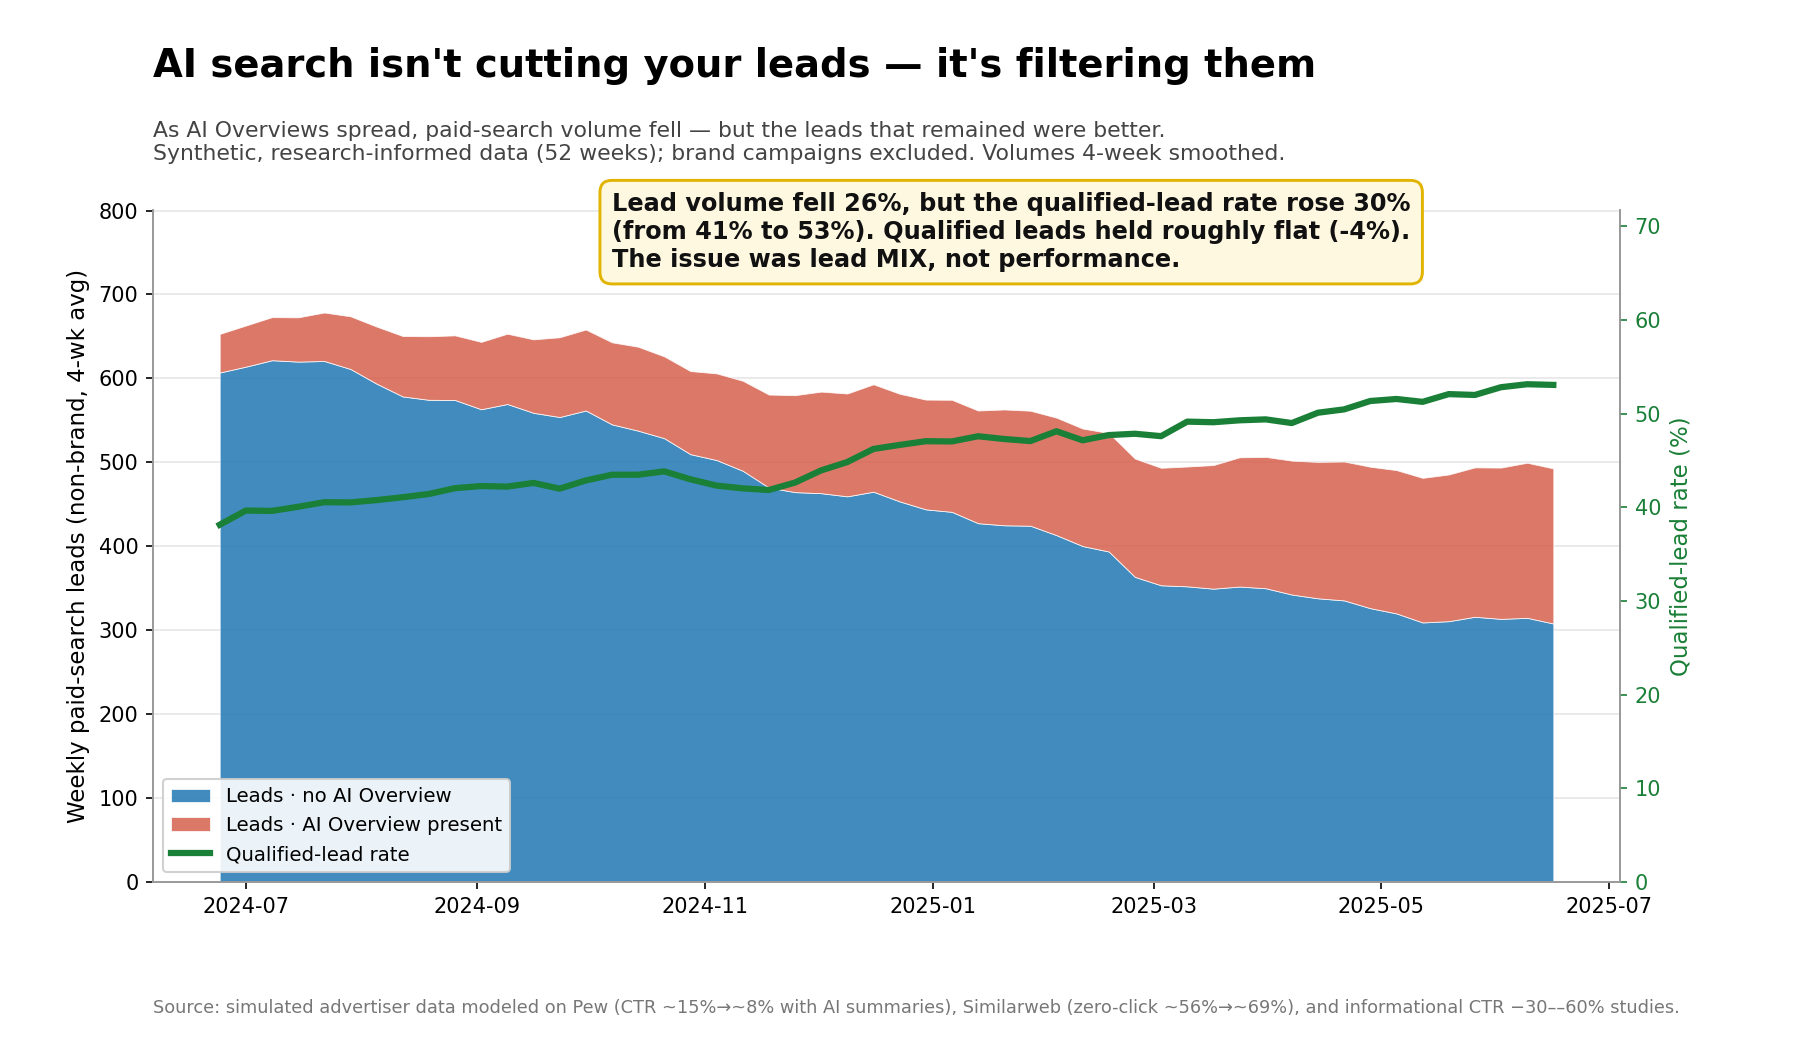

In [6]:
from IPython.display import Image

A.make_hero_chart(nonbrand, h)
Image(filename=str(A.CHART_PATH))

## Recommendation

**Don't cut paid search — reallocate it.**

1. Shift budget from informational to commercial/transactional intent (CPQL gap:
   ~$958 vs ~$152).
2. Rebuild landing pages around proof — comparison, calculators, demos, case
   studies — not generic informational content.
3. Manage to **qualified-lead rate** and **revenue per visitor**, not raw leads.

In an answer-engine world, you don't win back the clicks AI is taking. You win
the visitors who still have a reason to click.